<center>
    <img src="https://github.com/TUIlmenauAMS/MLfAS_Tutorials/blob/master/images/mlfasp.png?raw=1">
</center>

#### Prof. Dr. -Ing. Gerald Schuller <br> Jupyter Notebook: Renato Profeta

[Applied Media Systems Group](https://www.tu-ilmenau.de/en/applied-media-systems-group/) <br>
[Technische Universität Ilmenau](https://www.tu-ilmenau.de/)

# Variational Autoencoder (VAE)

The "Denoising Autoencoder" was robust against noise at its input, the audio signal. The "Variational Autoencoder" (VAE) now is robust against noise in its encoded domain, the "latent representation" in the "latent space".

In [8]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/6KzbMf9UTtg?rel=0" frameborder="0" allow="accelerometer; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen referrerpolicy="strict-origin-when-cross-origin"></iframe>

In [9]:
%%html
<iframe width="900" height="400" src="https://jaan.io/what-is-variational-autoencoder-vae-tutorial/"></iframe>

https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73

Hence, similar to the Denoising Autoencoder, we also add a fixed noise during the training process, but instead at the input we add it to the encoded signal in the latent space. But the training could just find a solution where the latent representation just becomes very big, which would effectively "drown out" the noise, because it would appear relatively smaller.

Hence we introduce a "regularizer" term, which is added to the reconstruction loss function (usually the mean squared error). This is an added term for the loss function, usually with a factor for weighing the importance of the regularizer.

This regularizer term is minimized, if the "mean value", meaning the output of our original autoencoder, is minimized. This "punishes" large values in the encoded domain and keeps the small in the training.

We could now just train this network in this way. But to help the training, there is a parallel network which outputs the variance of the added noise for each element of the encoded signal in the latent space. In this way the training can start with very little noise to help the training find a useful and suitable representation.

To avoid the system staying in the no noise state, there is an additional component in the regularizer term, which is minimized if the added noise has unit variance, meaning a variance of value 1 for each component of the encoded latent representation. This effectively "punishes" too little or too much noise (too little more than too much).

Hence for this regularizer term we need a measure for how different the current noise distribution is from the desired (Gaussian) noise distribution with zero mean and unit variance.

In [10]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/eTAAetCXO8M?rel=0" frameborder="0" allow="accelerometer; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen referrerpolicy="strict-origin-when-cross-origin"></iframe>

Let the current mean, from our usual autoencder, be $\mu$  , and the current standard deviation be $\sigma$ . In **Bayesian terms** this is called the **"posterior (observed) distribution”**. These are vectors of the size of the dimension of our latent space, meaning each element of the output vecor x of the encoder has its own mean and standard deviation.

Then our current noise probability distribution is:

$$\large
q(x) = \dfrac{1}{\sigma \sqrt{2\pi}} e^{\frac{-1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
$$

in our case the division by the standard deviation vector above is an element wise division, meaning we don't take into account cross-correlations.

Our desired probability distribution with $\sigma=1$ and $\mu=0$ is:

$$\large
p(x) = \dfrac{1}{\sigma \sqrt{2\pi}} e^{\frac{-1}{2}\left(x\right)^2}
$$

This is also called the **"prior (assumed) distribution"**.

A common information theoretic measure of how different 2 distributions p(x) and q(x) are is the “Kullback-Leibler Divergence" (KL-Divergence):

$$\large
D_{KL}\left(p \lVert q \right) = \int p(x) \log \left(\frac{p(x)}{q(x)} \right) dx
$$

In [11]:
%%html
<iframe width="900" height="400" src="https://en.wikipedia.org/wiki/Relative_entropy"></iframe>

Because we assume that the distributions of the different elements of our distributions are uncorrelated, we can simply sum up or average the KL-Divergences of each element in latent space, and our "variational loss" *vl* becomes:

$$\large
vl= \sum_{j=1}^J D_{KL} \left(p_j \lVert q_j \right)
$$

where $p_j=p(x_j)$ and $q_j=q(x_j)$

According to Appendix B of the paper:

Kingma and Welling. Auto-Encoding Variational Bayes, ICLR, 2014, https://arxiv.org/abs/1312.6114 this becomes:

$$\large
vl = - \dfrac{1}{2} \sum_{j=1}^J \left( 1 + \log \left(\sigma_j^2 \right) - \mu_j^2 - \sigma_j^2 \right)
$$

or in Pytorch and Python, with mu= $\mu$ and std= $\sigma$ :

`vl=-0.5*torch.mean(1+ 2*torch.log(std)-mu.pow(2) -(std.pow(2)))`

We can now compare this to a simple mean squared error function to our ideal of mu=0 and std=1:

`vl=torch.mean(mu.pow(2)+(1-std).pow(2))`

We can now plot it for mu=0 and standard deviation std ranging from 0 to 2:

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device=", device)

device= cpu


In [13]:
def variational_loss(mu, std):
    #returns the varialtional loss from arguments mean and standard deviation std
    #see also: see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    #https://arxiv.org/abs/1312.6114
    vl=-0.5*torch.mean(1+ 2*torch.log(std)-mu.pow(2) -(std.pow(2)))
    return vl

def variational_loss2(mu, std):
    #returns the varialtional loss from arguments mean and standard deviation std
    #alternative: mean squared distance from ideal mu=0 and std=1:
    vl=torch.mean(mu.pow(2)+(1-std).pow(2))
    return vl

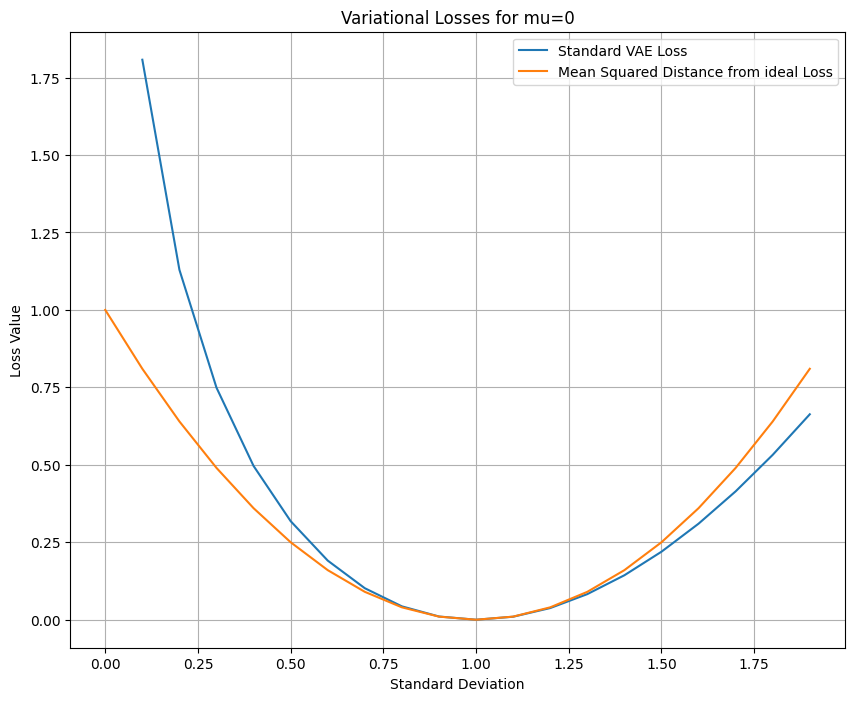

In [14]:
#Testing:
#compare the variational losses for different standard deviations std and mu=0:
std=np.arange(0,20)
vloss=torch.zeros(std.shape)
vloss2=torch.zeros(std.shape)
for std_ in std:
    vloss[std_]=variational_loss(torch.tensor([0.0]),torch.tensor(0.1*std_))
    vloss2[std_]=variational_loss2(torch.tensor([0.0]),torch.tensor([0.1*std_]))

plt.figure(figsize=(10,8))
plt.plot(0.1*std,np.array(vloss))
plt.plot(0.1*std,np.array(vloss2))
plt.ylabel('Loss Value')
plt.xlabel('Standard Deviation')
plt.title('Variational Losses for mu=0')
plt.legend(('Standard VAE Loss', 'Mean Squared Distance from ideal Loss'))
plt.grid()

Here we can see that both loss functions have the same minimum at *std=1*, as expected. But we see that the standard VAE loss has a steeper increase towards lower variances and less increase to higher variances.

This means that low variances, the case of less noise, is more "punished" by the standard VAE loss, hence the training will be less likely to find a low noise solution.

We now have two network outputs to train:

`Yencmean=model.encodermean(X)`, which corresponds to our prevous encoder, and:

`Yencstd=model.encoderstd(X)`, which just produces the currently "allowable" standard deviation for each "mean" output during
the training process.

Since now our loss function consists of two components, we combine them in the training loop using a "Lagrange multiplier" to
combine them in an overall loss value.

In [15]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/RVE1bRVX-Y0?rel=0" frameborder="0" allow="accelerometer; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen referrerpolicy="strict-origin-when-cross-origin"></iframe>

In [16]:
%%html
<iframe width="900" height="400" src="https://en.wikipedia.org/wiki/Lagrange_multiplier"></iframe>

The Lagrange multiplier simply weights the two components to achieve a desired trade-off between them. In our
case it looks like this:

```python
mse=loss_fn(Ypred, Y)
vl=variational_loss(Yencmean, Yencstd)
#vl=variational_loss2(Yencmean, Yencstd)
loss= mse + 0.01*vl```

where the factor "0.01" is our Lagrange multiplier.

Here we also see that we can choose between the two mentioned variational losses. *"variational_loss2"* is mean squared distance loss from above, the other is the standard VAE loss.

## Experiments

In our experiments the program first read in 2 speech files, as a simple training set. It is read in such that each file is one batch, using the function signal2pytorch(x).

It then defines the actual autoencoder in:

```python
class Convautoenc(nn.Module):
    def __init__(self):
        super(Convautoenc, self).__init__()
        #Analysis Filterbank with downsampling of N=8*1024, filter length of 2N, but only 32 outputs:
        #for the mean values:
        self.conv1mean=nn.Conv1d(in_channels=1, out_channels=32, kernel_size=8*2048, stride=8*1024, padding=8*1024-1, bias=True) #Padding for 'same' filters (kernel_size/2-1)
       #for the standard devieation values:
       self.conv1std=nn.Conv1d(in_channels=1, out_channels=32, kernel_size=8*2048, stride=8*1024, padding=8*1024-1, bias=True) #Padding for 'same' filters (kernel_size/2-1)

       #Synthesis filter bank:
       self.synconv1=nn.ConvTranspose1d(in_channels=32, out_channels=1, kernel_size=8*2048, stride=8*1024, padding=8*1024-1, bias=True)

    def encodermean(self, x):
        #Analysis:
        x = self.conv1mean(x)
        y = torch.tanh(x)
        return y
      
    def encoderstd(self, x):
        #Analysis:
        x = self.conv1std(x)
        y = torch.abs(torch.tanh(x))
        return y
      
    def decoder(self, y):
        #Synthesis:
        xrek= self.synconv1(y)
        return xrek
      
    def forward(self, x):
        Yencmean=model.encodermean(x)
        Yencstd=model.encoderstd(x)
        #Yvariational= torch.normal(Yencmean, Yencstd)
        Yvariational= Yencmean + Yencstd*torch.randn_like(Yencstd)
        #for the randn_like see also: https://github.com/pytorch/examples/blob/master/vae/main.py
        Ypred=model.decoder(Yvariational)
        return Ypred, Yencmean, Yencstd
```

Observe that the autoencoder uses filter kernel-sizes of 8\*2048, strides of 8\*1024, but we only use 32 channels. This means we have a very tight bottleneck here. The factor 8 here is for experimentation. Replace it by, e.g., 1. Then we have shorter filters, a shorter stride, and the bottleneck becomes less tight, but the results will be much more noisy!

Now, in addition to our previous encoder, which we here can call "conv1mean". It is an encoder for the standard deviation of the added noise in the encoded domain, which we call "conv1std".

#### torch.randn_like

In [17]:
%%html
<iframe width="900" height="400" src="https://pytorch.org/docs/stable/generated/torch.randn_like.html"></iframe>

#### Full Code for the VAE Model

In [18]:
# -*- coding: utf-8 -*-
__author__ = 'Gerald Schuller'
__copyright__ = 'G.S.'

"""
convolutional variational autoencoder for audio signals.
Denoising autoencoder is robust against noise at its input,
a variational autoencoder is robust against noise in its encoded domain.
Gerald Schuller, April 2020.
""";

# Ported to Jupyter Notebook by Renato Profeta, December 2020

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import scipy.io.wavfile as wav

In [20]:
if sys.version_info[0] < 3:
    # for Python 2
    import cPickle as pickle
else:
    # for Python 3
    import pickle

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device=", device)

device= cpu


In [21]:
def signal2pytorch(x):
    #Function to convert a signal vector x, like a mono audio signal, into a 3-d Tensor that conv1d of Pytorch expects,
    #https://pytorch.org/docs/stable/nn.html
    #Argument x: a 1-d signal as numpy array
    #input x[batch,sample]
    #output: 3-d Tensor X for conv1d input.
    #for conv1d Input: (N,Cin,Lin), Cin: numer of input channels (e.g. for stereo), Lin: length of signal, N: number of Batches (signals)
    X = np.expand_dims(x, axis=0)  #add channels dimension (here only 1 channel)
    if len(x.shape)==1: #mono:
        X = np.expand_dims(X, axis=0)  #add batch dimension (here only 1 batch)
    X=torch.from_numpy(X)
    X=X.type(torch.Tensor)
    X=X.permute(1,0,2)  #make batch dimension first
    return X

In [22]:
class Convautoenc(nn.Module):
    def __init__(self):
        super(Convautoenc, self).__init__()
        #Analysis Filterbank with downsampling of N=8*1024, filter length of 2N, but only 32 outputs:
        #for the mean values:
        self.conv1mean=nn.Conv1d(in_channels=1, out_channels=32, kernel_size=8*2048, stride=8*1024, padding=8*1024-1, bias=True) #Padding for 'same' filters (kernel_size/2-1)
        #for the standard devieation values:
        self.conv1std=nn.Conv1d(in_channels=1, out_channels=32, kernel_size=8*2048, stride=8*1024, padding=8*1024-1, bias=True) #Padding for 'same' filters (kernel_size/2-1)

        #Synthesis filter bank:
        self.synconv1=nn.ConvTranspose1d(in_channels=32, out_channels=1, kernel_size=8*2048, stride=8*1024, padding=8*1024-1, bias=True)

    def encodermean(self, x):
        #Analysis:
        x = self.conv1mean(x)
        y = torch.tanh(x)
        return y

    def encoderstd(self, x):
        #Analysis:
        x = self.conv1std(x)
        y = torch.abs(torch.tanh(x))
        return y

    def decoder(self, y):
        #Synthesis:
        xrek= self.synconv1(y)
        return xrek

    def forward(self, x):
        Yencmean=model.encodermean(x)
        Yencstd=model.encoderstd(x)
        #Yvariational= torch.normal(Yencmean, Yencstd)
        Yvariational= Yencmean + Yencstd*torch.randn_like(Yencstd)
        #for the randn_like see also: https://github.com/pytorch/examples/blob/master/vae/main.py
        Ypred=model.decoder(Yvariational)
        return Ypred, Yencmean, Yencstd

In [23]:
def variational_loss(mu, std):
    #returns the varialtional loss from arguments mean and standard deviation std
    #see also: see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    #https://arxiv.org/abs/1312.6114
    vl=-0.5*torch.mean(1+ 2*torch.log(std)-mu.pow(2) -(std.pow(2)))
    return vl

def variational_loss2(mu, std):
    #returns the varialtional loss from arguments mean and standard deviation std
    #alternative: mean squared distance from ideal mu=0 and std=1:
    vl=torch.mean(mu.pow(2)+(1-std).pow(2))
    return vl

In [24]:
import librosa

In [33]:
!git clone https://github.com/TUIlmenauAMS/MLfAS_Tutorials

fatal: destination path 'MLfAS_Tutorials' already exists and is not an empty directory.


In [32]:
#alternative: speech:
#make training set with batch of 2 speech signals:
batch=2;
#fs, x0= wav.read('./MLfAS_Tutorials/audio/test2.wav') #get size of the speech files, all need to be identical
x0, fs = librosa.load("./MLfAS_Tutorials/audio/ACDC - Back In Black Intro.wav", mono=True, sr=None, duration=6, offset=13)
xlen=max(x0.shape)
x=np.zeros((batch,xlen))
for b in range(batch):
    if b==0:
        #fs, x0= wav.read('./audio/test2.wav')
        x0, fs = librosa.load("./MLfAS_Tutorials/audio/ACDC - Back In Black Intro.wav"", mono=True, sr=None, duration=6, offset=13)
    if b==1:
        fs, x0= wav.read('./audio/test3.wav')
        #x0, fs = librosa.load("./audio/Iron Maiden - Aces High.mp3", mono=True, sr=None, duration=6, offset=8)
    x0= x0/max(x0)
    x[b,:]=x0
    #x=x*1.0/2**15 #normalize
    print("x.shape=", x.shape)
    X=signal2pytorch(x).to(device) #Convert to pytorch format, batch is first dimension
    print("X.shape=", X.shape)
    print("Generate Model:")
    model = Convautoenc().to(device)
    print('Total number of parameters: %i' % (sum(p.numel() for p in model.parameters() if p.requires_grad)))
    print("Def. loss function:")
    loss_fn = nn.MSELoss()  #MSE

SyntaxError: unterminated string literal (detected at line 11) (2972760985.py, line 11)

In [ ]:
Ypred, Yencmean, Yencstd = model(X)

#Ypred=Ypred.detach()
outputlen=len(Ypred[0,0,:]) #length of the signal at the output of the network.
print("outputlen=", outputlen)

Y=X[:,:,:outputlen]  #the target signal with same length as model output

print("Input X.shape=", X.shape )
print("Target Y.shape=", Y.shape)
print("Target Y=", Y)
#print("max(max(Y))=", max(max(max(Y))))
#print("min(min(Y))=", min(min(min(Y))))
print("Y.type()=", Y.type())

learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)#, betas=(0.9, 0.999))
"""
try:
    checkpoint = torch.load("audio_variational_autoenc.torch",map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    #optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
except IOError:
    print("fresh start")
"""
#optimrandomdir_pytorch.optimizer(model, loss_fn, X, Ypred, iterations=300, startingscale=1.0, endscale=0.0)
#Ypred=model(X)
#Ypred=Ypred.detach()
#print("Ypred=", Ypred)

#randdir=True # True for optimization of random direction, False for pytorch optimization
randdir=False

### Experiment 1

We let the program run like a conventional variational autoencoder. In the "for" loop for the training we have:

In [ ]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/tb9AEXh3Sd4?rel=0" frameborder="0" allow="accelerometer; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen referrerpolicy="strict-origin-when-cross-origin"></iframe>

In [ ]:
if randdir==True:
    #optimization of weights using method of random directions:
    optimrandomdir_pytorch.optimizer(model, loss_fn, X, Y, iterations=100000, startingscale=0.25, endscale=0.0)
    #--End optimization of random directions------------------------
else:
    for epoch in range(2000):
        #Ypred, Yencmean, Yencstd = model(X)
        #mean values from the encoder network:
        Yencmean=model.encodermean(X)

        #standard deviation values from the network:
        Yencstd=model.encoderstd(X)
        #unit standard deviation:
        #Yencstd=torch.ones(Yencmean.shape)

        Yvariational= Yencmean + Yencstd*torch.randn_like(Yencstd)
        Ypred=model.decoder(Yvariational)

        mse=loss_fn(Ypred, Y)
        vl=variational_loss(Yencmean, Yencstd)
        #vl=variational_loss2(Yencmean, Yencstd)
        loss= mse + 0.01*vl
        #loss= mse
        if epoch%10==0:
             print(epoch, "mse=", mse.item(), "variational loss=", vl.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #"""
    torch.save({#'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()}, "audio_variational_autoenc.torch")
    #"""


In [ ]:
print("MSE=", loss_fn(Ypred, Y).item(), "Variational Loss:", variational_loss(Yencmean, Yencstd).item())
ww = model.state_dict()   #read obtained weights
print("ww=", ww)
#Plot obtained weights:
plt.figure(figsize=(10,8))
plt.plot(np.transpose(np.array(ww['conv1mean.weight'][0:1,0,:].cpu())))
plt.plot(np.transpose(np.array(ww['conv1std.weight'][0:1,0,:].cpu())))
plt.plot(np.transpose(np.array(ww['synconv1.weight'][0:1,0,:].cpu())))
plt.legend(('Encoder Analysis filter 0, mean','Encoder Analysis filter 0, std', 'Decoder Filter 0'))
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('The Encoder and Decoder Filter Coefficients')
plt.grid()

After training the program first displays the weights of the autoencoder and decoder, then it plots the coefficents in the encoded domain, and the added noise controlled by the "encoderstd" network. The latter should be as close as possible to 1.

It first lets the autoencoder run on the training set without additional noise, and plays back the result. Observe that it already sounds a little noisy.

Then it add noise with unit standard deviation (value of 1).
Observe that it sounds more noisy.

In [ ]:
#Test on training set:

#predictions=model(X).cpu() # Make Predictions based on the obtained weights, on training set
#noisy case:
#predictions, Yencmean, Yencstd = model(X)
Yencmean=model.encodermean(X)

#no noise case
predclean=model.decoder(Yencmean)
predclean=predclean.detach() #no noise case
predclean=np.array(predclean.cpu())

#Add gaussian noise with unit standard deviation to encoded signal:
Yvariational= Yencmean + torch.randn_like(Yencmean)
predictions=model.decoder(Yvariational)

predictions=predictions.detach()
predictions=np.array(predictions.cpu())
Yencmean=np.array(Yencmean.detach().cpu())
Yencstd=np.array(Yencstd.detach().cpu())
print("Yencstd.shape=",Yencstd.shape)

Y=np.array(Y.cpu()) #target
#print("Y=",Y)
print("predictions.shape=", predictions.shape)
#convert to numpy:
#https://discuss.pytorch.org/t/how-to-transform-variable-into-numpy/104/2

In [ ]:
import IPython.display as ipd

In [ ]:
#Plot target signal and output of autoencoder:

for b in range(batch):
    #print("np.reshape(Yencstd[b,:,:],(1,-1))", np.reshape(Yencstd[b,:,:],(1,-1)))
    plt.figure(figsize=(10,8))
    plt.plot(np.reshape(Yencmean[b,:,:],(1,-1))[0,:])
    plt.plot(np.reshape(Yencstd[b,:,:],(1,-1))[0,:])
    plt.legend(('Encoded Mean', 'Encoded Standard Deviation'))
    plt.title('The Encoded Domain, Mean and Standard Deviation')
    plt.grid()
    plt.figure(figsize=(10,8))
    plt.plot(np.array(Y[b,0,:]))
    plt.plot(predictions[b,0,:])
    plt.legend(('Target','Predicted'))
    plt.title('The Target and Noisy Predicted Signal, batch '+str(b))
    plt.xlabel('Sample')
    plt.grid()

    #No noise case:
    xrek=predclean[b,0,:]  #remove unnecessary dimension for playback
    xrek=np.clip(xrek, -1.0,1.0)
    wav.write('testrekvaeclean'+str(b)+'.wav', fs, np.int16(2**15*xrek))
    print('"The training set output for clean encoded signal for batch'+str(b)+'"')
    display(ipd.Audio(2**15*xrek,rate=fs))

    xrek=predictions[b,0,:]  #remove unnecessary dimension for playback
    xrek=np.clip(xrek, -1.0,1.0)
    wav.write('testrekvae'+str(b)+'.wav', fs, np.int16(2**15*xrek))
    print('"The training set output for noisy encoded signal for batch'+str(b)+'"')
    display(ipd.Audio(2**15*xrek,rate=fs))

Then it uses a validation signal without and with noise. Observe that it appears less robust to the noise.

Then it plays the result for a validation input and on pure noise on the input. In both cases it produces a mix of the training set speech pieces.

In [ ]:
#Test on Verification set:
#fs, x= wav.read('test.wav')
x, fs = librosa.load("./audio/Iron Maiden - Aces High.mp3", mono=True, sr=None, duration=6, offset=0)
#fs, x= wav.read('test2.wav')
#x=x*1.0/2**15 #normalize
x=x/max(x)

print("The verification set input to the variational autoencoder")
display(ipd.Audio(2**14*x,rate=fs))
X=signal2pytorch(x).to(device)
Yencmean=model.encodermean(X)

predclean=model.decoder(Yencmean)
predclean=predclean.detach() #no noise case
predclean=np.array(predclean.cpu())

#No noise case:
xrek=predclean[0,0,:]  #remove unnecessary dimension for playback
xrek=np.clip(xrek, -1.0,1.0)
wav.write('testvervaeclean'+str(b)+'.wav', fs, np.int16(2**15*xrek))
print("The verification set output for clean encoded signal")
display(ipd.Audio(2**15*xrek, rate=fs))

#Add gaussian noise with unit standard deviation:
Yvariational= Yencmean + torch.randn_like(Yencmean)
predictions= model.decoder(Yvariational) # Make Predictions based on the obtained weights, on verification set
predictions=predictions.detach()
predictions=np.array(predictions.cpu())
b=0
plt.figure(figsize=(10,8))
plt.plot(np.array(X[b,0,:].cpu()))
plt.plot(predictions[b,0,:])
plt.legend(('Original','Predicted'))
plt.title('Verification, the Original and Predicted Signal, batch ')
plt.xlabel('Sample')
plt.grid()
xrek=predictions[:,0,:]
xrek=np.transpose(xrek)
xrek=np.clip(xrek, -1.0,1.0)
wav.write('testver.wav', fs, np.int16(2**15*xrek))
print("The verification set output for noisy encoded signal")
display(ipd.Audio('testver.wav', rate=fs))
print("Only noise as encoded signal")

Yvariational=  torch.randn_like(Yencmean)
predictions= model.decoder(Yvariational) # Make Predictions based on the obtained weights, on verification set
predictions=predictions.detach()
predictions=np.array(predictions.cpu())
xrek=predictions[:,0,:]
xrek=np.transpose(xrek)
xrek=np.clip(xrek, -1.0,1.0)
wav.write('noisevarout.wav', fs, np.int16(2**15*xrek))
print("The decoded signal")
display(ipd.Audio('noisevarout.wav', rate=fs))

### Experiment 2:

Use our alternative variational loss function for the training:

`vl=variational_loss2(Yencmean, Yencstd)`

In [ ]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/NdQhjo_8vdY?rel=0" frameborder="0" allow="accelerometer; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen referrerpolicy="strict-origin-when-cross-origin"></iframe>

In [ ]:
#alternative: speech:
#make training set with batch of 2 speech signals:
batch=2;
#fs, x0= wav.read('./audio/test2.wav') #get size of the speech files, all need to be identical
x0, fs = librosa.load("./audio/Iron Maiden - The Number Of The Beast.mp3", mono=True, sr=None, duration=6, offset=13)
xlen=max(x0.shape)
x=np.zeros((batch,xlen))
for b in range(batch):
    if b==0:
        #fs, x0= wav.read('./audio/test2.wav')
        x0, fs = librosa.load("./audio/Iron Maiden - The Number Of The Beast.mp3", mono=True, sr=None, duration=6, offset=13)
    if b==1:
        #fs, x0= wav.read('./audio/test3.wav')
        x0, fs = librosa.load("./audio/Iron Maiden - Aces High.mp3", mono=True, sr=None, duration=6, offset=8)
    x0= x0/max(x0)
    x[b,:]=x0
    #x=x*1.0/2**15 #normalize
    print("x.shape=", x.shape)
    X=signal2pytorch(x).to(device) #Convert to pytorch format, batch is first dimension
    print("X.shape=", X.shape)
    print("Generate Model:")
    model = Convautoenc().to(device)
    print('Total number of parameters: %i' % (sum(p.numel() for p in model.parameters() if p.requires_grad)))
    print("Def. loss function:")
    loss_fn = nn.MSELoss()  #MSE

In [ ]:
Ypred, Yencmean, Yencstd = model(X)

#Ypred=Ypred.detach()
outputlen=len(Ypred[0,0,:]) #length of the signal at the output of the network.
print("outputlen=", outputlen)

Y=X[:,:,:outputlen]  #the target signal with same length as model output

print("Input X.shape=", X.shape )
print("Target Y.shape=", Y.shape)
print("Target Y=", Y)
#print("max(max(Y))=", max(max(max(Y))))
#print("min(min(Y))=", min(min(min(Y))))
print("Y.type()=", Y.type())

learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)#, betas=(0.9, 0.999))
"""
try:
    checkpoint = torch.load("audio_variational_autoenc.torch",map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    #optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
except IOError:
    print("fresh start")
"""
#optimrandomdir_pytorch.optimizer(model, loss_fn, X, Ypred, iterations=300, startingscale=1.0, endscale=0.0)
#Ypred=model(X)
#Ypred=Ypred.detach()
#print("Ypred=", Ypred)

#randdir=True # True for optimization of random direction, False for pytorch optimization
randdir=False

In [ ]:
if randdir==True:
    #optimization of weights using method of random directions:
    optimrandomdir_pytorch.optimizer(model, loss_fn, X, Y, iterations=100000, startingscale=0.25, endscale=0.0)
    #--End optimization of random directions------------------------
else:
    for epoch in range(2000):
        #Ypred, Yencmean, Yencstd = model(X)
        #mean values from the encoder network:
        Yencmean=model.encodermean(X)

        #standard deviation values from the network:
        Yencstd=model.encoderstd(X)
        #unit standard deviation:
        #Yencstd=torch.ones(Yencmean.shape)

        Yvariational= Yencmean + Yencstd*torch.randn_like(Yencstd)
        Ypred=model.decoder(Yvariational)

        mse=loss_fn(Ypred, Y)
        #vl=variational_loss(Yencmean, Yencstd)
        vl=variational_loss2(Yencmean, Yencstd)
        loss= mse + 0.01*vl
        #loss= mse
        if epoch%10==0:
             print(epoch, "mse=", mse.item(), "variational loss=", vl.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #"""
    torch.save({#'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()}, "audio_variational_autoenc.torch")
    #"""


In [ ]:
print("MSE=", loss_fn(Ypred, Y).item(), "Variational Loss:", variational_loss(Yencmean, Yencstd).item())
ww = model.state_dict()   #read obtained weights
print("ww=", ww)
#Plot obtained weights:
plt.figure(figsize=(10,8))
plt.plot(np.transpose(np.array(ww['conv1mean.weight'][0:1,0,:].cpu())))
plt.plot(np.transpose(np.array(ww['conv1std.weight'][0:1,0,:].cpu())))
plt.plot(np.transpose(np.array(ww['synconv1.weight'][0:1,0,:].cpu())))
plt.legend(('Encoder Analysis filter 0, mean','Encoder Analysis filter 0, std', 'Decoder Filter 0'))
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('The Encoder and Decoder Filter Coefficients')
plt.grid()

In [ ]:
#Test on training set:

#predictions=model(X).cpu() # Make Predictions based on the obtained weights, on training set
#noisy case:
#predictions, Yencmean, Yencstd = model(X)
Yencmean=model.encodermean(X)

#no noise case
predclean=model.decoder(Yencmean)
predclean=predclean.detach() #no noise case
predclean=np.array(predclean.cpu())

#Add gaussian noise with unit standard deviation to encoded signal:
Yvariational= Yencmean + torch.randn_like(Yencmean)
predictions=model.decoder(Yvariational)

predictions=predictions.detach()
predictions=np.array(predictions.cpu())
Yencmean=np.array(Yencmean.detach().cpu())
Yencstd=np.array(Yencstd.detach().cpu())
print("Yencstd.shape=",Yencstd.shape)

Y=np.array(Y.cpu()) #target
#print("Y=",Y)
print("predictions.shape=", predictions.shape)
#convert to numpy:
#https://discuss.pytorch.org/t/how-to-transform-variable-into-numpy/104/2

In [ ]:
import IPython.display as ipd

In [ ]:
#Plot target signal and output of autoencoder:

for b in range(batch):
    #print("np.reshape(Yencstd[b,:,:],(1,-1))", np.reshape(Yencstd[b,:,:],(1,-1)))
    plt.figure(figsize=(10,8))
    plt.plot(np.reshape(Yencmean[b,:,:],(1,-1))[0,:])
    plt.plot(np.reshape(Yencstd[b,:,:],(1,-1))[0,:])
    plt.legend(('Encoded Mean', 'Encoded Standard Deviation'))
    plt.title('The Encoded Domain, Mean and Standard Deviation')
    plt.grid()
    plt.figure(figsize=(10,8))
    plt.plot(np.array(Y[b,0,:]))
    plt.plot(predictions[b,0,:])
    plt.legend(('Target','Predicted'))
    plt.title('The Target and Noisy Predicted Signal, batch '+str(b))
    plt.xlabel('Sample')
    plt.grid()

    #No noise case:
    xrek=predclean[b,0,:]  #remove unnecessary dimension for playback
    xrek=np.clip(xrek, -1.0,1.0)
    wav.write('testrekvaeclean'+str(b)+'.wav', fs, np.int16(2**15*xrek))
    print('"The training set output for clean encoded signal for batch'+str(b)+'"')
    display(ipd.Audio(2**15*xrek,rate=fs))

    xrek=predictions[b,0,:]  #remove unnecessary dimension for playback
    xrek=np.clip(xrek, -1.0,1.0)
    wav.write('testrekvae'+str(b)+'.wav', fs, np.int16(2**15*xrek))
    print('"The training set output for noisy encoded signal for batch'+str(b)+'"')
    display(ipd.Audio(2**15*xrek,rate=fs))

Observe the plot of the added noise after training: It is now less close to 1, because this loss "punished" lower noise values less. This means the autoencoder is now more sensitive to noise. Even the "clean" version is not so clean.

In [ ]:
#Test on Verification set:
#fs, x= wav.read('test.wav')
x, fs = librosa.load("./audio/Iron Maiden - Aces High.mp3", mono=True, sr=None, duration=6, offset=0)
#fs, x= wav.read('test2.wav')
#x=x*1.0/2**15 #normalize
x=x/max(x)

print("The verification set input to the variational autoencoder")
display(ipd.Audio(2**14*x,rate=fs))
X=signal2pytorch(x).to(device)
Yencmean=model.encodermean(X)

predclean=model.decoder(Yencmean)
predclean=predclean.detach() #no noise case
predclean=np.array(predclean.cpu())

#No noise case:
xrek=predclean[0,0,:]  #remove unnecessary dimension for playback
xrek=np.clip(xrek, -1.0,1.0)
wav.write('testvervaeclean'+str(b)+'.wav', fs, np.int16(2**15*xrek))
print("The verification set output for clean encoded signal")
display(ipd.Audio(2**15*xrek, rate=fs))

#Add gaussian noise with unit standard deviation:
Yvariational= Yencmean + torch.randn_like(Yencmean)
predictions= model.decoder(Yvariational) # Make Predictions based on the obtained weights, on verification set
predictions=predictions.detach()
predictions=np.array(predictions.cpu())
b=0
plt.figure(figsize=(10,8))
plt.plot(np.array(X[b,0,:].cpu()))
plt.plot(predictions[b,0,:])
plt.legend(('Original','Predicted'))
plt.title('Verification, the Original and Predicted Signal, batch ')
plt.xlabel('Sample')
plt.grid()
xrek=predictions[:,0,:]
xrek=np.transpose(xrek)
xrek=np.clip(xrek, -1.0,1.0)
wav.write('testver.wav', fs, np.int16(2**15*xrek))
print("The verification set output for noisy encoded signal")
display(ipd.Audio('testver.wav', rate=fs))
print("Only noise as encoded signal")

Yvariational=  torch.randn_like(Yencmean)
predictions= model.decoder(Yvariational) # Make Predictions based on the obtained weights, on verification set
predictions=predictions.detach()
predictions=np.array(predictions.cpu())
xrek=predictions[:,0,:]
xrek=np.transpose(xrek)
xrek=np.clip(xrek, -1.0,1.0)
wav.write('noisevarout.wav', fs, np.int16(2**15*xrek))
print("The decoded signal")
display(ipd.Audio('noisevarout.wav', rate=fs))

Then it plays the result for a validation input and on pure noise on the input. Again In both cases it produces a mix of the training set speech pieces.

### Experiment 3

Use fixed noise with unit standard variance in the training process. This also means we don't need the variational loss anymore, since the added noise is fixed:

```python
Yencstd=torch.ones(Yencmean.shape)
loss= mse + 0.0*vl
```

In [ ]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/SzgRYTRJN5o?rel=0" frameborder="0" allow="accelerometer; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen referrerpolicy="strict-origin-when-cross-origin"></iframe>

In [ ]:
#alternative: speech:
#make training set with batch of 2 speech signals:
batch=2;
#fs, x0= wav.read('./audio/test2.wav') #get size of the speech files, all need to be identical
x0, fs = librosa.load("./audio/Iron Maiden - The Number Of The Beast.mp3", mono=True, sr=None, duration=6, offset=13)
xlen=max(x0.shape)
x=np.zeros((batch,xlen))
for b in range(batch):
    if b==0:
        #fs, x0= wav.read('./audio/test2.wav')
        x0, fs = librosa.load("./audio/Iron Maiden - The Number Of The Beast.mp3", mono=True, sr=None, duration=6, offset=13)
    if b==1:
        #fs, x0= wav.read('./audio/test3.wav')
        x0, fs = librosa.load("./audio/Iron Maiden - Aces High.mp3", mono=True, sr=None, duration=6, offset=8)
    x0= x0/max(x0)
    x[b,:]=x0
    #x=x*1.0/2**15 #normalize
    print("x.shape=", x.shape)
    X=signal2pytorch(x).to(device) #Convert to pytorch format, batch is first dimension
    print("X.shape=", X.shape)
    print("Generate Model:")
    model = Convautoenc().to(device)
    print('Total number of parameters: %i' % (sum(p.numel() for p in model.parameters() if p.requires_grad)))
    print("Def. loss function:")
    loss_fn = nn.MSELoss()  #MSE

In [ ]:
Ypred, Yencmean, Yencstd = model(X)

#Ypred=Ypred.detach()
outputlen=len(Ypred[0,0,:]) #length of the signal at the output of the network.
print("outputlen=", outputlen)

Y=X[:,:,:outputlen]  #the target signal with same length as model output

print("Input X.shape=", X.shape )
print("Target Y.shape=", Y.shape)
print("Target Y=", Y)
#print("max(max(Y))=", max(max(max(Y))))
#print("min(min(Y))=", min(min(min(Y))))
print("Y.type()=", Y.type())

learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)#, betas=(0.9, 0.999))
"""
try:
    checkpoint = torch.load("audio_variational_autoenc.torch",map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    #optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
except IOError:
    print("fresh start")
"""
#optimrandomdir_pytorch.optimizer(model, loss_fn, X, Ypred, iterations=300, startingscale=1.0, endscale=0.0)
#Ypred=model(X)
#Ypred=Ypred.detach()
#print("Ypred=", Ypred)

#randdir=True # True for optimization of random direction, False for pytorch optimization
randdir=False

In [ ]:
if randdir==True:
    #optimization of weights using method of random directions:
    optimrandomdir_pytorch.optimizer(model, loss_fn, X, Y, iterations=100000, startingscale=0.25, endscale=0.0)
    #--End optimization of random directions------------------------
else:
    for epoch in range(2000):
        #Ypred, Yencmean, Yencstd = model(X)
        #mean values from the encoder network:
        Yencmean=model.encodermean(X)

        #standard deviation values from the network:
        #Yencstd=model.encoderstd(X)
        #unit standard deviation:
        Yencstd=torch.ones(Yencmean.shape).to(device)

        Yvariational= Yencmean + Yencstd*torch.randn_like(Yencstd)
        Ypred=model.decoder(Yvariational)

        mse=loss_fn(Ypred, Y)
        #vl=variational_loss(Yencmean, Yencstd)
        vl=variational_loss2(Yencmean, Yencstd)
        loss= mse + 0*vl
        #loss= mse
        if epoch%10==0:
             print(epoch, "mse=", mse.item(), "variational loss=", vl.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #"""
    torch.save({#'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()}, "audio_variational_autoenc.torch")
    #"""


In [ ]:
print("MSE=", loss_fn(Ypred, Y).item(), "Variational Loss:", variational_loss(Yencmean, Yencstd).item())
ww = model.state_dict()   #read obtained weights
print("ww=", ww)
#Plot obtained weights:
plt.figure(figsize=(10,8))
plt.plot(np.transpose(np.array(ww['conv1mean.weight'][0:1,0,:].cpu())))
plt.plot(np.transpose(np.array(ww['conv1std.weight'][0:1,0,:].cpu())))
plt.plot(np.transpose(np.array(ww['synconv1.weight'][0:1,0,:].cpu())))
plt.legend(('Encoder Analysis filter 0, mean','Encoder Analysis filter 0, std', 'Decoder Filter 0'))
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('The Encoder and Decoder Filter Coefficients')
plt.grid()

In [ ]:
#Test on training set:

#predictions=model(X).cpu() # Make Predictions based on the obtained weights, on training set
#noisy case:
#predictions, Yencmean, Yencstd = model(X)
Yencmean=model.encodermean(X)

#no noise case
predclean=model.decoder(Yencmean)
predclean=predclean.detach() #no noise case
predclean=np.array(predclean.cpu())

#Add gaussian noise with unit standard deviation to encoded signal:
Yvariational= Yencmean + torch.randn_like(Yencmean)
predictions=model.decoder(Yvariational)

predictions=predictions.detach()
predictions=np.array(predictions.cpu())
Yencmean=np.array(Yencmean.detach().cpu())
Yencstd=np.array(Yencstd.detach().cpu())
print("Yencstd.shape=",Yencstd.shape)

Y=np.array(Y.cpu()) #target
#print("Y=",Y)
print("predictions.shape=", predictions.shape)
#convert to numpy:
#https://discuss.pytorch.org/t/how-to-transform-variable-into-numpy/104/2

In [ ]:
import IPython.display as ipd

In [ ]:
#Plot target signal and output of autoencoder:

for b in range(batch):
    #print("np.reshape(Yencstd[b,:,:],(1,-1))", np.reshape(Yencstd[b,:,:],(1,-1)))
    plt.figure(figsize=(10,8))
    plt.plot(np.reshape(Yencmean[b,:,:],(1,-1))[0,:])
    plt.plot(np.reshape(Yencstd[b,:,:],(1,-1))[0,:])
    plt.legend(('Encoded Mean', 'Encoded Standard Deviation'))
    plt.title('The Encoded Domain, Mean and Standard Deviation')
    plt.grid()
    plt.figure(figsize=(10,8))
    plt.plot(np.array(Y[b,0,:]))
    plt.plot(predictions[b,0,:])
    plt.legend(('Target','Predicted'))
    plt.title('The Target and Noisy Predicted Signal, batch '+str(b))
    plt.xlabel('Sample')
    plt.grid()

    #No noise case:
    xrek=predclean[b,0,:]  #remove unnecessary dimension for playback
    xrek=np.clip(xrek, -1.0,1.0)
    wav.write('testrekvaeclean'+str(b)+'.wav', fs, np.int16(2**15*xrek))
    print('"The training set output for clean encoded signal for batch'+str(b)+'"')
    display(ipd.Audio(2**15*xrek,rate=fs))

    xrek=predictions[b,0,:]  #remove unnecessary dimension for playback
    xrek=np.clip(xrek, -1.0,1.0)
    wav.write('testrekvae'+str(b)+'.wav', fs, np.int16(2**15*xrek))
    print('"The training set output for noisy encoded signal for batch'+str(b)+'"')
    display(ipd.Audio(2**15*xrek,rate=fs))

After training the plot with the added noise shows that it is indeed a constant 1. But after playing back the clean signal we can hear that this now sounds somewhat less clean than in the first case.

But on the plus side, it seems to be indeed more robust against noise in the encoded domain, sounding less noisy there.

In [ ]:
#Test on Verification set:
#fs, x= wav.read('test.wav')
x, fs = librosa.load("./audio/Iron Maiden - Aces High.mp3", mono=True, sr=None, duration=6, offset=0)
#fs, x= wav.read('test2.wav')
#x=x*1.0/2**15 #normalize
x=x/max(x)

print("The verification set input to the variational autoencoder")
display(ipd.Audio(2**14*x,rate=fs))
X=signal2pytorch(x).to(device)
Yencmean=model.encodermean(X)

predclean=model.decoder(Yencmean)
predclean=predclean.detach() #no noise case
predclean=np.array(predclean.cpu())

#No noise case:
xrek=predclean[0,0,:]  #remove unnecessary dimension for playback
xrek=np.clip(xrek, -1.0,1.0)
wav.write('testvervaeclean'+str(b)+'.wav', fs, np.int16(2**15*xrek))
print("The verification set output for clean encoded signal")
display(ipd.Audio(2**15*xrek, rate=fs))

#Add gaussian noise with unit standard deviation:
Yvariational= Yencmean + torch.randn_like(Yencmean)
predictions= model.decoder(Yvariational) # Make Predictions based on the obtained weights, on verification set
predictions=predictions.detach()
predictions=np.array(predictions.cpu())
b=0
plt.figure(figsize=(10,8))
plt.plot(np.array(X[b,0,:].cpu()))
plt.plot(predictions[b,0,:])
plt.legend(('Original','Predicted'))
plt.title('Verification, the Original and Predicted Signal, batch ')
plt.xlabel('Sample')
plt.grid()
xrek=predictions[:,0,:]
xrek=np.transpose(xrek)
xrek=np.clip(xrek, -1.0,1.0)
wav.write('testver.wav', fs, np.int16(2**15*xrek))
print("The verification set output for noisy encoded signal")
display(ipd.Audio('testver.wav', rate=fs))
print("Only noise as encoded signal")

Yvariational=  torch.randn_like(Yencmean)
predictions= model.decoder(Yvariational) # Make Predictions based on the obtained weights, on verification set
predictions=predictions.detach()
predictions=np.array(predictions.cpu())
xrek=predictions[:,0,:]
xrek=np.transpose(xrek)
xrek=np.clip(xrek, -1.0,1.0)
wav.write('noisevarout.wav', fs, np.int16(2**15*xrek))
print("The decoded signal")
display(ipd.Audio('noisevarout.wav', rate=fs))

And again In both cases it produces a mix of the training set speech pieces.

But keep in mind that this last case has the advantage that it does not need a neural network for the standard deviation prediction.